# **Day 72: Generative Adversarial Networks (GANs)**
*Module 11 - Advanced Deep Learning*

A GAN (Goodfellow et al., 2014) trains two networks against each other:
- the **generator** G turns random noise into fake samples;
- the **discriminator** D tries to tell real from fake.
G improves by fooling D. At equilibrium, G produces samples D cannot distinguish from real data. GANs produced the first photo-realistic synthetic images; in remote sensing they are used for super-resolution, SAR-to-optical translation, cloud removal and data augmentation.

> A GAN trains two networks against each other: a generator creates fake samples and a discriminator tries to spot them. As both improve, the generator learns to produce realistic data.
>
> *Example:* GANs have been used to generate synthetic satellite patches or to translate SAR images into optical-looking images.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, time
from sklearn.datasets import load_digits
torch.manual_seed(72); rng = np.random.default_rng(72)

## **1. The Objective**
$$\min_G\max_D\;\mathbb E_{\mathbf x\sim p_{data}}[\log D(\mathbf x)] + \mathbb E_{\mathbf z\sim p_z}[\log(1 - D(G(\mathbf z)))]$$
For a fixed G the optimal discriminator is $D^*(\mathbf x) = \frac{p_{data}}{p_{data} + p_G}$, and the generator's objective becomes $2\,JS(p_{data}\,\|\,p_G) - \log 4$: GANs minimise the Jensen-Shannon divergence.

In practice G maximises $\log D(G(\mathbf z))$ instead of minimising $\log(1 - D(G(\mathbf z)))$ (the **non-saturating** loss): when D confidently rejects fakes early in training, the original loss gives almost no gradient.

## **2. A GAN on a 2-D Mixture of Gaussians**
Real data: 8 Gaussians on a ring. Can G learn to produce all 8 modes?

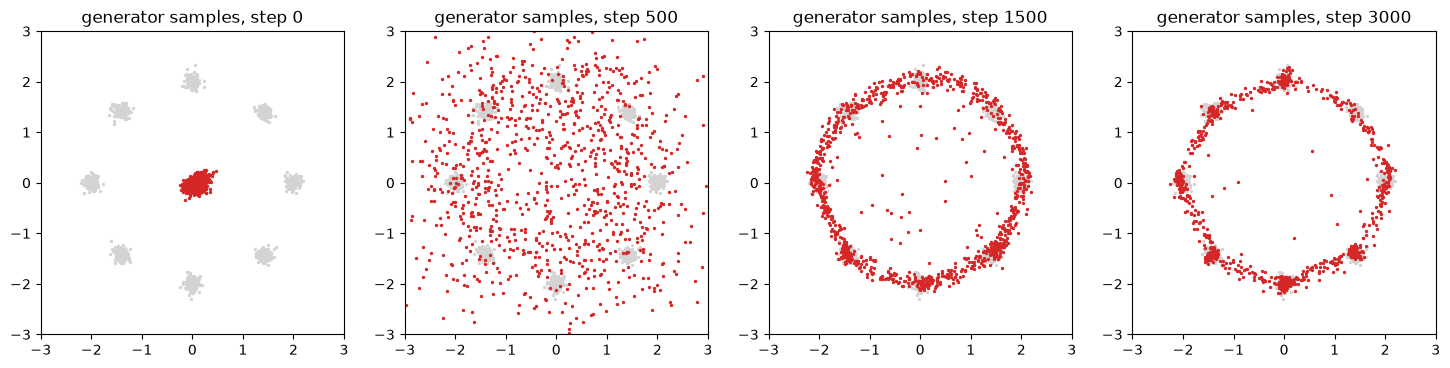

trained in 39s


In [2]:
def real_ring(n):
    k = rng.integers(0, 8, n); ang = 2 * np.pi * k / 8
    return torch.tensor(np.c_[2 * np.cos(ang), 2 * np.sin(ang)] + rng.normal(0, 0.08, (n, 2)), dtype=torch.float32)

def mlp(d_in, d_out, h=128, out_act=None):
    layers = [nn.Linear(d_in, h), nn.LeakyReLU(0.2), nn.Linear(h, h), nn.LeakyReLU(0.2), nn.Linear(h, d_out)]
    return nn.Sequential(*layers, *( [out_act] if out_act else []))

def train_gan_2d(steps=3000, z_dim=8, lr=2e-4, seed=0):
    torch.manual_seed(seed); G, D = mlp(z_dim, 2), mlp(2, 1)
    oG, oD = torch.optim.Adam(G.parameters(), lr, betas=(0.5, 0.999)), torch.optim.Adam(D.parameters(), lr, betas=(0.5, 0.999))
    snaps = {}
    for step in range(steps + 1):
        x = real_ring(256); fake = G(torch.randn(256, z_dim))
        lossD = F.binary_cross_entropy_with_logits(D(x), torch.ones(256, 1)) + F.binary_cross_entropy_with_logits(D(fake.detach()), torch.zeros(256, 1))
        oD.zero_grad(); lossD.backward(); oD.step()
        lossG = F.binary_cross_entropy_with_logits(D(fake), torch.ones(256, 1))           # non-saturating generator loss
        oG.zero_grad(); lossG.backward(); oG.step()
        if step in (0, 500, 1500, steps):
            with torch.no_grad(): snaps[step] = G(torch.randn(1000, z_dim)).numpy()
    return G, D, snaps

t0 = time.perf_counter(); G2, D2, snaps = train_gan_2d()
fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
ref = real_ring(1000).numpy()
for ax, (step, s) in zip(axes, snaps.items()):
    ax.scatter(*ref.T, s=2, c="lightgrey"); ax.scatter(*s.T, s=2, c="C3"); ax.set(xlim=(-3, 3), ylim=(-3, 3), title=f"generator samples, step {step}"); ax.set_aspect("equal")
plt.show(); print(f"trained in {time.perf_counter() - t0:.0f}s")

### Mode collapse
A common failure: G finds a few outputs that fool D and produces only those (covering only some of the 8 modes). Let us count covered modes.

In [3]:
def modes_covered(samples, tol=0.3):
    centres = np.c_[2 * np.cos(2 * np.pi * np.arange(8) / 8), 2 * np.sin(2 * np.pi * np.arange(8) / 8)]
    d = np.linalg.norm(samples[:, None] - centres[None], axis=2); near = d.min(1) < tol
    return len(np.unique(d.argmin(1)[near])), near.mean()
for seed in range(3):
    G_, _, sn = train_gan_2d(steps=2000, seed=seed); m, q = modes_covered(sn[2000])
    print(f"seed {seed}: modes covered {m}/8 | fraction of high-quality samples {q:.2f}")

seed 0: modes covered 8/8 | fraction of high-quality samples 0.56


seed 1: modes covered 8/8 | fraction of high-quality samples 0.60


seed 2: modes covered 8/8 | fraction of high-quality samples 0.51


## **3. A Convolutional GAN for Digits (DCGAN-Style)**
Radford et al. (2016) guidelines: strided (transposed) convolutions instead of pooling, BatchNorm in G, LeakyReLU in D, Tanh output, Adam with beta1 = 0.5.

DCGAN trained in 214s


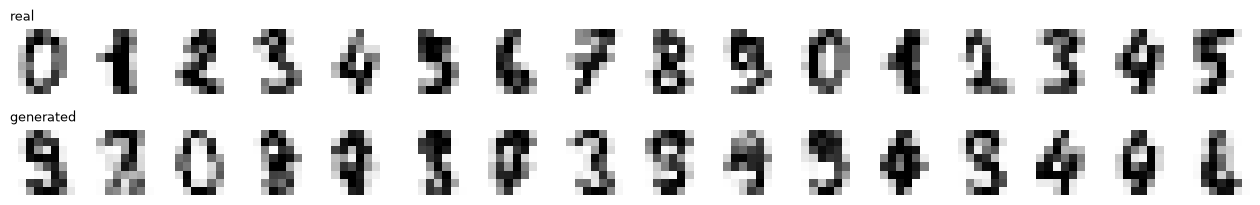

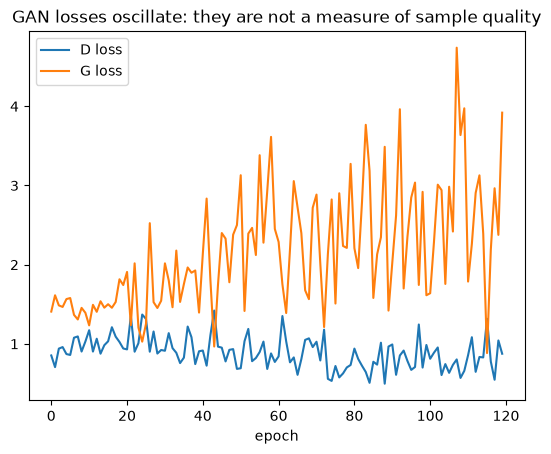

In [4]:
Xd, yd = load_digits(return_X_y=True)
real_imgs = torch.tensor(Xd / 8.0 - 1.0, dtype=torch.float32).view(-1, 1, 8, 8)      # scale to [-1, 1]
z_dim = 32
G = nn.Sequential(nn.Linear(z_dim, 64 * 2 * 2), nn.Unflatten(1, (64, 2, 2)), nn.BatchNorm2d(64), nn.ReLU(),
                  nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),            # 2 -> 4
                  nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Tanh())                                 # 4 -> 8
D = nn.Sequential(nn.Conv2d(1, 32, 4, 2, 1), nn.LeakyReLU(0.2), nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
                  nn.Flatten(), nn.Linear(64 * 2 * 2, 1))
oG, oD = torch.optim.Adam(G.parameters(), 2e-4, betas=(0.5, 0.999)), torch.optim.Adam(D.parameters(), 2e-4, betas=(0.5, 0.999))
fixed_z = torch.randn(32, z_dim); hist = []
t0 = time.perf_counter()
for epoch in range(120):
    for idx in torch.randperm(len(real_imgs)).split(64):
        x = real_imgs[idx]; b = len(x); fake = G(torch.randn(b, z_dim))
        lossD = F.binary_cross_entropy_with_logits(D(x), torch.full((b, 1), 0.9)) + F.binary_cross_entropy_with_logits(D(fake.detach()), torch.zeros(b, 1))   # one-sided label smoothing
        oD.zero_grad(); lossD.backward(); oD.step()
        lossG = F.binary_cross_entropy_with_logits(D(fake), torch.ones(b, 1)); oG.zero_grad(); lossG.backward(); oG.step()
    hist.append((lossD.item(), lossG.item()))
print(f"DCGAN trained in {time.perf_counter() - t0:.0f}s")
G.eval()
with torch.no_grad(): gen = G(fixed_z).numpy()
fig, axes = plt.subplots(2, 16, figsize=(16, 2.4))
for j in range(16):
    axes[0, j].imshow(Xd[j].reshape(8, 8), cmap="gray_r"); axes[1, j].imshow(gen[j, 0], cmap="gray_r"); axes[0, j].axis("off"); axes[1, j].axis("off")
axes[0, 0].set_title("real", loc="left", fontsize=9); axes[1, 0].set_title("generated", loc="left", fontsize=9); plt.show()
h = np.array(hist); plt.plot(h[:, 0], label="D loss"); plt.plot(h[:, 1], label="G loss"); plt.legend(); plt.xlabel("epoch"); plt.title("GAN losses oscillate: they are not a measure of sample quality"); plt.show()

### Is the generator just copying training images?
Check the distance from each generated image to its **nearest** training image. Memorisation would give near-zero distances.

In [5]:
with torch.no_grad(): many = G(torch.randn(500, z_dim)).view(500, -1).numpy()
real_flat = real_imgs.view(len(real_imgs), -1).numpy()
nn_gen = np.sqrt(((many[:, None] - real_flat[None]) ** 2).sum(-1)).min(1)
nn_real = np.sqrt(((real_flat[:300, None] - real_flat[None, 300:]) ** 2).sum(-1)).min(1)
print(f"median nearest-training distance: generated {np.median(nn_gen):.2f} | real held-out {np.median(nn_real):.2f}")

median nearest-training distance: generated 2.76 | real held-out 2.30


## **4. Conditional GANs and Image-to-Image Translation**
- **Conditional GAN** (Mirza & Osindero, 2014): feed a label (or any condition) to both G and D, so we can ask for a specific class.
- **pix2pix** (Isola et al., 2017): condition on an **input image**; G is a U-Net mapping image A -> image B; loss = adversarial + L1 to the target. Used for SAR -> optical translation, map -> image, cloud removal.
- **CycleGAN** (Zhu et al., 2017): unpaired translation with a cycle-consistency loss (e.g. summer <-> winter imagery).
- **SRGAN / ESRGAN**: super-resolution (e.g. Sentinel-2 10 m -> 2.5 m). Caution: GAN details can be **hallucinated**; do not measure small objects from GAN-enhanced imagery without validation.

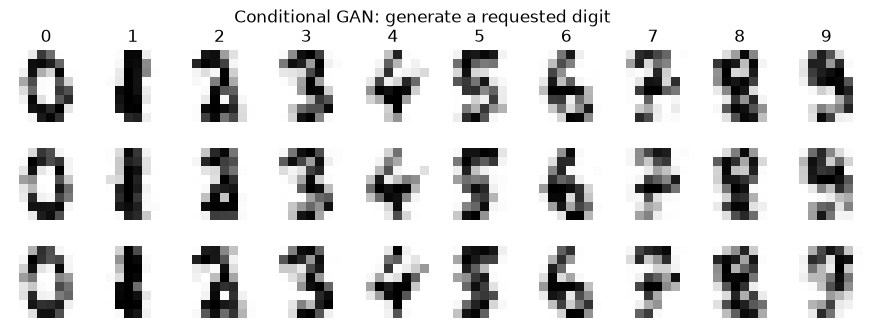

In [6]:
class CondG(nn.Module):
    def __init__(self, z_dim=32):
        super().__init__(); self.emb = nn.Embedding(10, 16); self.net = nn.Sequential(nn.Linear(z_dim + 16, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 64), nn.Tanh())
    def forward(self, z, c): return self.net(torch.cat([z, self.emb(c)], 1))
class CondD(nn.Module):
    def __init__(self):
        super().__init__(); self.emb = nn.Embedding(10, 16); self.net = nn.Sequential(nn.Linear(64 + 16, 256), nn.LeakyReLU(0.2), nn.Linear(256, 256), nn.LeakyReLU(0.2), nn.Linear(256, 1))
    def forward(self, x, c): return self.net(torch.cat([x, self.emb(c)], 1))
cG, cD = CondG(), CondD(); oG, oD = torch.optim.Adam(cG.parameters(), 2e-4, betas=(0.5, 0.999)), torch.optim.Adam(cD.parameters(), 2e-4, betas=(0.5, 0.999))
xr_all, yr_all = real_imgs.view(-1, 64), torch.tensor(yd)
for epoch in range(150):
    for idx in torch.randperm(len(xr_all)).split(64):
        x, c = xr_all[idx], yr_all[idx]; b = len(x); fake = cG(torch.randn(b, 32), c)
        lD = F.binary_cross_entropy_with_logits(cD(x, c), torch.full((b, 1), 0.9)) + F.binary_cross_entropy_with_logits(cD(fake.detach(), c), torch.zeros(b, 1))
        oD.zero_grad(); lD.backward(); oD.step()
        lG = F.binary_cross_entropy_with_logits(cD(fake, c), torch.ones(b, 1)); oG.zero_grad(); lG.backward(); oG.step()
cG.eval()
with torch.no_grad(): cg = cG(torch.randn(30, 32), torch.arange(10).repeat(3)).numpy()
fig, axes = plt.subplots(3, 10, figsize=(11, 3.6))
for i in range(30): axes[i // 10, i % 10].imshow(cg[i].reshape(8, 8), cmap="gray_r"); axes[i // 10, i % 10].axis("off")
for j in range(10): axes[0, j].set_title(str(j))
plt.suptitle("Conditional GAN: generate a requested digit"); plt.show()

# **Part 2: Going Deeper**

### Wasserstein GAN with gradient penalty (WGAN-GP)
The JS divergence saturates when real and fake distributions do not overlap, giving useless gradients. WGAN (Arjovsky et al., 2017) uses the **Earth Mover's (Wasserstein-1) distance**; the "critic" must be 1-Lipschitz, enforced by a **gradient penalty** (Gulrajani et al., 2017):
$$\mathcal L_{critic} = \mathbb E[C(\tilde{\mathbf x})] - \mathbb E[C(\mathbf x)] + \lambda\,\mathbb E\big[(\lVert\nabla_{\hat{\mathbf x}}C(\hat{\mathbf x})\rVert_2 - 1)^2\big]$$
The critic loss correlates with sample quality and training is more stable; it often reduces mode collapse.

WGAN-GP: modes covered 2/8, high-quality fraction 0.01 (123s)


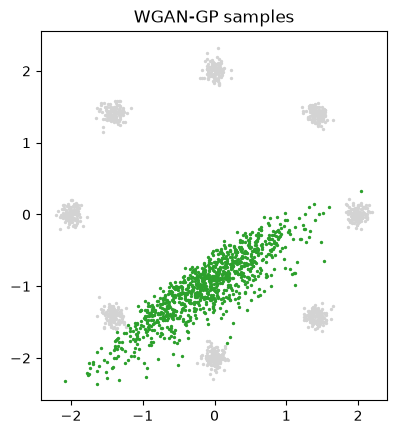

In [7]:
def train_wgan_gp(steps=2000, z_dim=8, n_critic=5, lam=10.0, seed=0):
    torch.manual_seed(seed); G, C = mlp(z_dim, 2), mlp(2, 1)
    oG, oC = torch.optim.Adam(G.parameters(), 1e-4, betas=(0.5, 0.9)), torch.optim.Adam(C.parameters(), 1e-4, betas=(0.5, 0.9))
    for step in range(steps):
        for _ in range(n_critic):
            x = real_ring(256); fake = G(torch.randn(256, z_dim)).detach()
            eps = torch.rand(256, 1); xh = (eps * x + (1 - eps) * fake).requires_grad_(True)
            grad = torch.autograd.grad(C(xh).sum(), xh, create_graph=True)[0]
            lossC = C(fake).mean() - C(x).mean() + lam * ((grad.norm(dim=1) - 1) ** 2).mean()
            oC.zero_grad(); lossC.backward(); oC.step()
        lossG = -C(G(torch.randn(256, z_dim))).mean(); oG.zero_grad(); lossG.backward(); oG.step()
    with torch.no_grad(): return G(torch.randn(1000, z_dim)).numpy()
t0 = time.perf_counter(); s_w = train_wgan_gp()
m, q = modes_covered(s_w); print(f"WGAN-GP: modes covered {m}/8, high-quality fraction {q:.2f} ({time.perf_counter() - t0:.0f}s)")
plt.scatter(*ref.T, s=2, c="lightgrey"); plt.scatter(*s_w.T, s=2, c="C2"); plt.gca().set_aspect("equal"); plt.title("WGAN-GP samples"); plt.show()

### Evaluating generative models
No single number is perfect. **FID** (Frechet Inception Distance) compares the mean and covariance of real vs generated samples in a feature space; lower is better. Also check **precision/recall** of the generated distribution (quality vs diversity), nearest-neighbour memorisation, and downstream usefulness (does training on synthetic data help a classifier?).

In [8]:
from scipy.linalg import sqrtm
def frechet_distance(a, b):
    mu1, mu2 = a.mean(0), b.mean(0); s1, s2 = [np.cov(z, rowvar=False) + 1e-3 * np.eye(z.shape[1]) for z in (a, b)]   # small ridge: constant border pixels make covariances singular
    covmean = sqrtm(s1 @ s2).real; return float(((mu1 - mu2) ** 2).sum() + np.trace(s1 + s2 - 2 * covmean))
noise_imgs = np.random.default_rng(0).uniform(-1, 1, many.shape)
print(f"Frechet distance to real digits (pixel space): DCGAN {frechet_distance(real_flat, many):.2f} | uniform noise {frechet_distance(real_flat, noise_imgs):.2f} | "
      f"held-out real {frechet_distance(real_flat[:900], real_flat[900:]):.2f}")

Frechet distance to real digits (pixel space): DCGAN 0.58 | uniform noise 39.42 | held-out real 1.18


### Responsible use
Generated imagery can be mistaken for real observations (fake satellite images have been used in disinformation). Label synthetic data clearly, never present GAN-enhanced images as measurements, and validate any physical quantity derived from them.

## **Practice Problems**
1. Train the 2-D GAN with the **saturating** generator loss $\log(1 - D(G(z)))$. Does it learn as well?
2. Make D much stronger (5 D steps per G step) or much weaker in the 2-D GAN. What happens?
3. Use the conditional generator to create 100 synthetic examples of each digit; train a classifier on synthetic data only and test it on real digits.
4. *(Advanced)* Compare modes covered by the vanilla GAN and WGAN-GP over 3 seeds each.

In [9]:
# Solution 1
torch.manual_seed(0); Gs, Ds = mlp(8, 2), mlp(2, 1); oG_, oD_ = torch.optim.Adam(Gs.parameters(), 2e-4, betas=(0.5, 0.999)), torch.optim.Adam(Ds.parameters(), 2e-4, betas=(0.5, 0.999))
for step in range(2000):
    x = real_ring(256); fake = Gs(torch.randn(256, 8))
    lD = F.binary_cross_entropy_with_logits(Ds(x), torch.ones(256, 1)) + F.binary_cross_entropy_with_logits(Ds(fake.detach()), torch.zeros(256, 1)); oD_.zero_grad(); lD.backward(); oD_.step()
    lG = -F.binary_cross_entropy_with_logits(Ds(fake), torch.zeros(256, 1)); oG_.zero_grad(); lG.backward(); oG_.step()     # minimise log(1 - D(G(z)))
with torch.no_grad(): print("saturating loss: modes covered %d/8, quality %.2f" % modes_covered(Gs(torch.randn(1000, 8)).numpy()))
# Solution 2: a 5x stronger discriminator (5 D updates per G update)
torch.manual_seed(0); Gk, Dk = mlp(8, 2), mlp(2, 1); oGk, oDk = torch.optim.Adam(Gk.parameters(), 2e-4, betas=(0.5, 0.999)), torch.optim.Adam(Dk.parameters(), 2e-4, betas=(0.5, 0.999))
for step in range(1500):
    for _ in range(5):
        x = real_ring(256); fk = Gk(torch.randn(256, 8)).detach()
        lD = F.binary_cross_entropy_with_logits(Dk(x), torch.ones(256, 1)) + F.binary_cross_entropy_with_logits(Dk(fk), torch.zeros(256, 1)); oDk.zero_grad(); lD.backward(); oDk.step()
    lG = F.binary_cross_entropy_with_logits(Dk(Gk(torch.randn(256, 8))), torch.ones(256, 1)); oGk.zero_grad(); lG.backward(); oGk.step()
with torch.no_grad(): print("5 D steps per G step: modes covered %d/8, quality %.2f" % modes_covered(Gk(torch.randn(1000, 8)).numpy()))
# Solution 3
from sklearn.linear_model import LogisticRegression
with torch.no_grad(): synth = cG(torch.randn(1000, 32), torch.arange(10).repeat(100)).numpy()
clf = LogisticRegression(max_iter=3000).fit(synth, np.tile(np.arange(10), 100))
print("classifier trained on synthetic digits only, accuracy on real digits:", round(clf.score(real_flat, yd), 3))
# Solution 4
for name, fn in [("vanilla GAN", lambda s: train_gan_2d(steps=2000, seed=s)[2][2000]), ("WGAN-GP", lambda s: train_wgan_gp(steps=1000, seed=s))]:
    print(name, [modes_covered(fn(s))[0] for s in range(3)])

saturating loss: modes covered 8/8, quality 0.48


5 D steps per G step: modes covered 7/8, quality 0.40


classifier trained on synthetic digits only, accuracy on real digits: 0.814


vanilla GAN [8, 8, 8]


WGAN-GP [1, 8, 2]


## **Key References**
- Goodfellow, I. et al. (2014). Generative adversarial nets. *NeurIPS 27*.
- Radford, A., Metz, L., & Chintala, S. (2016). Unsupervised representation learning with deep convolutional generative adversarial networks. *ICLR 2016*.
- Arjovsky, M., Chintala, S., & Bottou, L. (2017). Wasserstein generative adversarial networks. *ICML 2017*.
- Gulrajani, I., Ahmed, F., Arjovsky, M., Dumoulin, V., & Courville, A. (2017). Improved training of Wasserstein GANs. *NeurIPS 30*.
- Isola, P., Zhu, J.-Y., Zhou, T., & Efros, A. A. (2017). Image-to-image translation with conditional adversarial networks. *CVPR 2017*.
- Heusel, M. et al. (2017). GANs trained by a two time-scale update rule converge to a local Nash equilibrium. *NeurIPS 30* (FID).
- Zhao, B. et al. (2021). Deep fake geography? When geospatial data encounter artificial intelligence. *Cartography and Geographic Information Science*, 48(4), 338-352.